In [4]:
import jax.numpy as jnp
from collections import namedtuple
from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
import time
import numpy as np
import torch
from collections import namedtuple
from sklearn.datasets import make_blobs
from torchdyn.core import NeuralODE
from torchcfm.utils import *

In [6]:
def wasserstein_distance(point_cloud1, point_cloud2):
    pairwise_distances = cdist(point_cloud1, point_cloud2, metric='euclidean')
    
    total_distance = 0.0
    for i in range(len(point_cloud1)):
        total_distance += np.min(pairwise_distances[i])
        
    return total_distance / len(point_cloud1)

## 1) Testing conditional flow matching on gaussian blob data

In [8]:
X_np, _ = make_blobs(n_samples=1000, n_features=2, centers=[[0, 0]], random_state=42)
Y_np, _ = make_blobs(n_samples=1000, n_features=2, centers=[[0, 10], [0, -10]], random_state=43)

X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)

n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]

def infinite_iterator(data):
    while True:
        yield data

DataLoader = namedtuple("DataLoader", ["source_iter", "target_iter"])
train_dtld = DataLoader(source_iter=infinite_iterator(X_train),
                        target_iter=infinite_iterator(Y_train))
valid_dtld = DataLoader(source_iter=infinite_iterator(X_valid),
                        target_iter=infinite_iterator(Y_valid))

# Sample a batch (convert to torch tensor)
X = torch.from_numpy(np.array(next(train_dtld.source_iter))).float()
Y = torch.from_numpy(np.array(next(train_dtld.target_iter))).float()

5000: loss 6.543 time 3199.99


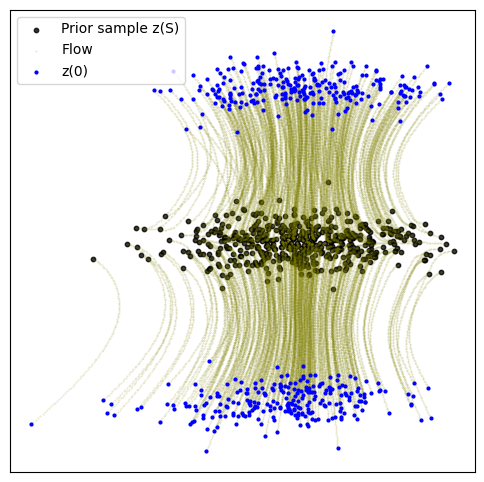

CPU times: user 9h 56min 26s, sys: 1min 40s, total: 9h 58min 7s
Wall time: 54min 55s


In [10]:
%%time
sigma = 0.1
dim = 2
model = MLP(dim=dim, time_varying=True)  
optimizer = torch.optim.Adam(model.parameters())
FM = ConditionalFlowMatcher(sigma=sigma)
n_epochs = 5000

start = time.time()
for k in range(n_epochs):
    optimizer.zero_grad()

    # Sample flow-matching pairs
    t, xt, ut = FM.sample_location_and_conditional_flow(X, Y)

    # Forward pass
    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    # Backward pass
    loss.backward()
    optimizer.step()

    # Logging
    if (k + 1) == 5000:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end

        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            # Dummy X_new_tensor for now (replace with actual test points if needed)
            X_new_tensor = torch.from_numpy(np.array(next(valid_dtld.source_iter))).float()
            traj = node.trajectory(
                X_new_tensor,
                t_span=torch.linspace(0, 1, 100),
            )
            plot_trajectories(traj.cpu().numpy())

# Optionally:
# from IPython.display import clear_output
# clear_output()
